# Week 1 Assignment — Time Series Foundations
### Multi-Agent Forecasting Project

**Name:** [Your Name]  
**Date:** 2026-06-09  

---

This assignment covers the fundamentals of time series analysis that will form the backbone of our multi-agent forecasting system. Complete all sections. Cells marked `# YOUR CODE HERE` require your implementation.

**Topics covered:**
1. Pandas Time Series Basics
2. Visualization with Matplotlib
3. Time Series Components (Trend, Seasonality, Cyclic, Random)
4. Moving Averages
5. Lag Features
6. Putting It All Together

In [1]:
# Run this cell first — installs/imports everything you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Section 1 — Pandas Time Series Basics

Pandas has first-class support for time series data. The key building blocks are:
- `pd.to_datetime()` — parse strings/integers into datetime objects
- `pd.date_range()` — generate a sequence of dates
- `DatetimeIndex` — the index type that unlocks time-aware operations
- `.resample()` — group and aggregate by time frequency

**Read:** [Pandas Time Series Documentation](https://pandas.pydata.org/docs/user_guide/timeseries.html)

In [2]:
# --- EXAMPLE: Creating a time series in pandas ---

# Generate a daily date range
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Create a simple series with random values
np.random.seed(42)
values = np.random.randn(len(dates)).cumsum() + 100

ts = pd.Series(values, index=dates, name='price')
print("Type of index:", type(ts.index))
print("\nFirst 5 entries:")
print(ts.head())
print("\nSlicing by date string (January only):")
print(ts['2023-01'].head())

Type of index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

First 5 entries:
2023-01-01    100.496714
2023-01-02    100.358450
2023-01-03    101.006138
2023-01-04    102.529168
2023-01-05    102.295015
Freq: D, Name: price, dtype: float64

Slicing by date string (January only):
2023-01-01    100.496714
2023-01-02    100.358450
2023-01-03    101.006138
2023-01-04    102.529168
2023-01-05    102.295015
Freq: D, Name: price, dtype: float64


### Exercise 1.1 — Build Your Own Time Series

Using `pd.date_range`, create a **monthly** time series from `2020-01` to `2024-12` representing simulated monthly sales figures (use `np.random.randint(500, 2000, ...)` for values). Store it in a variable called `sales`.

In [3]:
# Exercise 1.1 Solution
np.random.seed(0)

# 1. Create a monthly date range from 2020-01 to 2024-12
dates_monthly = pd.date_range(start='2020-01', end='2024-12', freq='MS')

# 2. Create random integer sales values
sales_values = np.random.randint(500, 2000, size=len(dates_monthly))

# 3. Create a pd.Series named 'sales'
sales = pd.Series(sales_values, index=dates_monthly, name='sales')

print(sales)

2020-01-01    1184
2020-02-01    1059
2020-03-01    1716
2020-04-01    1335
2020-05-01    1263
2020-06-01    1883
2020-07-01    1533
2020-08-01     777
2020-09-01    1099
2020-10-01    1594
2020-11-01    1996
2020-12-01    1100
2021-01-01    1920
2021-02-01     814
2021-03-01    1205
2021-04-01    1051
2021-05-01     587
2021-06-01     674
2021-07-01    1349
2021-08-01    1037
2021-09-01    1345
2021-10-01     572
2021-11-01    1277
2021-12-01     615
2022-01-01    1476
2022-02-01    1255
2022-03-01    1955
2022-04-01     948
2022-05-01    1350
2022-06-01     599
2022-07-01    1701
2022-08-01    1255
2022-09-01    1297
2022-10-01    1159
2022-11-01    1671
2022-12-01    1410
2023-01-01     923
2023-02-01    1812
2023-03-01    1789
2023-04-01    1197
2023-05-01    1139
2023-06-01    1044
2023-07-01    1043
2023-08-01    1214
2023-09-01     744
2023-10-01     651
2023-11-01    1175
2023-12-01    1010
2024-01-01    1983
2024-02-01    1382
2024-03-01    1707
2024-04-01     528
2024-05-01  

### Exercise 1.2 — Resampling

Resample `sales` to **quarterly** frequency using `.resample('QE').sum()` and store the result in `sales_quarterly`. Print both the original and resampled series length.

In [4]:
# Exercise 1.2 Solution
sales_quarterly = sales.resample('QE').sum()

print("Monthly length:", len(sales))
print("Quarterly length:", len(sales_quarterly))
print(sales_quarterly)

Monthly length: 60
Quarterly length: 20
2020-03-31    3959
2020-06-30    4481
2020-09-30    3409
2020-12-31    4690
2021-03-31    3939
2021-06-30    2312
2021-09-30    3731
2021-12-31    2464
2022-03-31    4686
2022-06-30    2897
2022-09-30    4253
2022-12-31    4240
2023-03-31    4524
2023-06-30    3380
2023-09-30    3001
2023-12-31    2836
2024-03-31    5072
2024-06-30    2458
2024-09-30    3461
2024-12-31    2496
Freq: QE-DEC, Name: sales, dtype: int64


---
## Section 2 — Visualization with Matplotlib

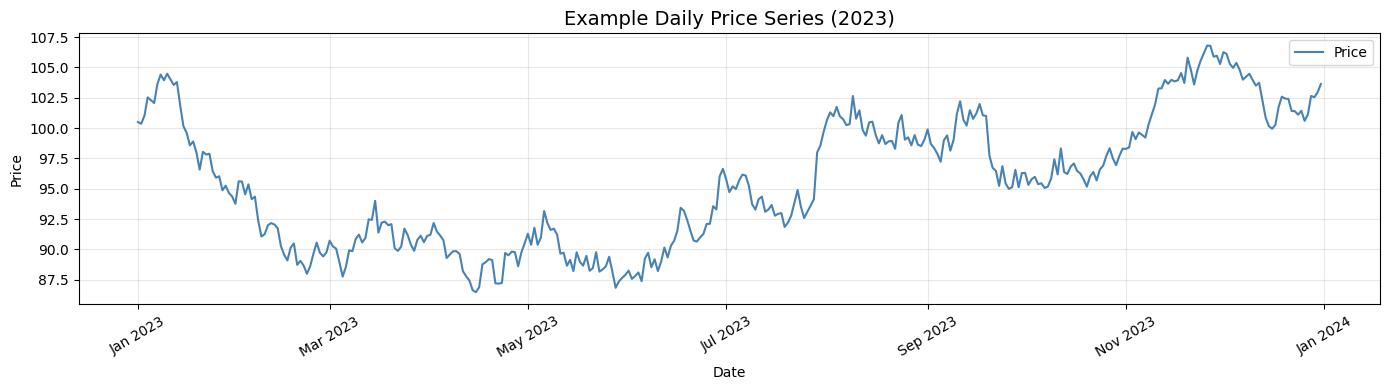

In [5]:
# --- EXAMPLE: Proper time series plot ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.5, label='Price')
ax.set_title('Example Daily Price Series (2023)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 2.1 — Plot Your Sales Series

Plot your `sales` series (monthly) and `sales_quarterly` on the **same figure** with two subplots (one above the other). Include titles, axis labels, and formatted x-axis ticks.

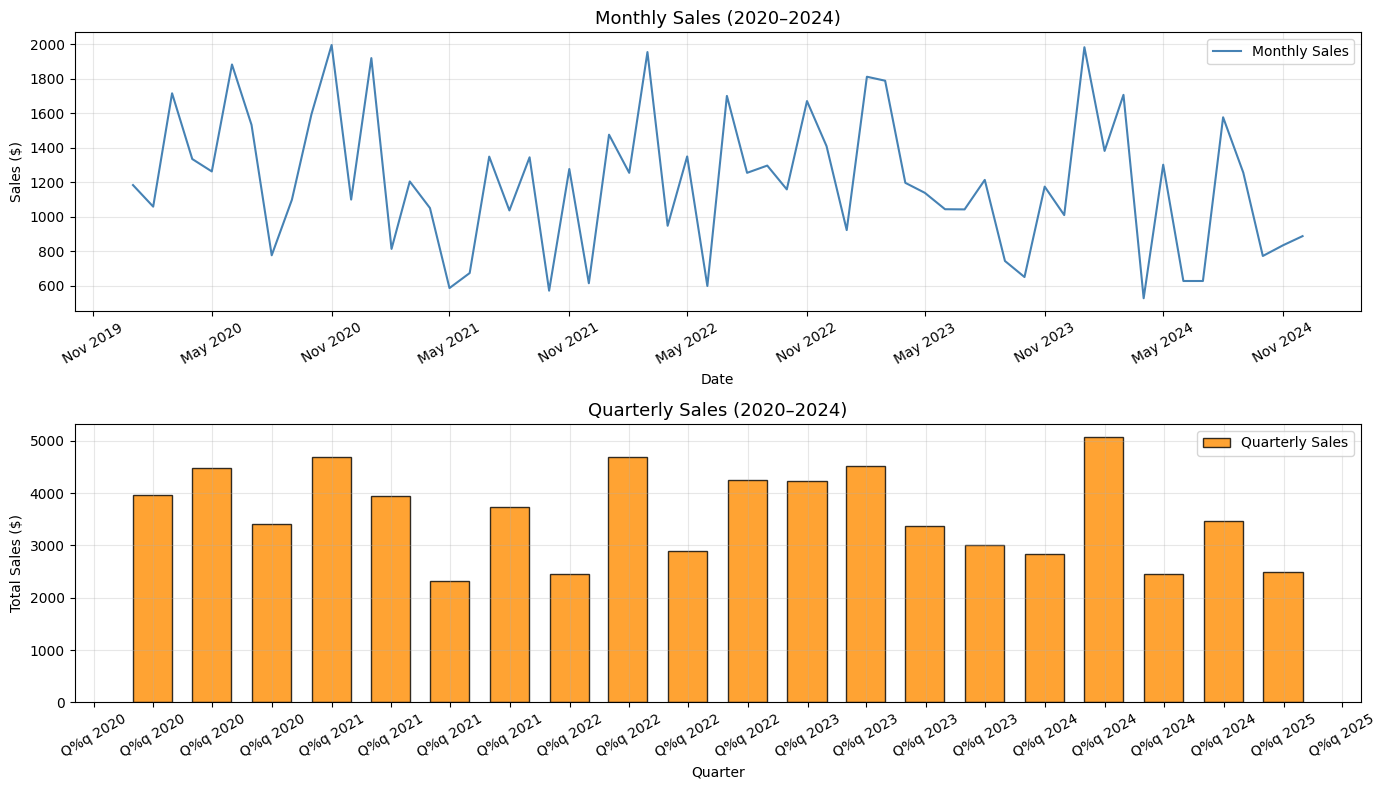

In [6]:
# Exercise 2.1 Solution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Top subplot: monthly sales
ax1.plot(sales.index, sales.values, color='steelblue', linewidth=1.5, label='Monthly Sales')
ax1.set_title('Monthly Sales (2020–2024)', fontsize=13)
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales ($)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.tick_params(axis='x', rotation=30)
ax1.legend()

# Bottom subplot: quarterly sales bar chart
ax2.bar(sales_quarterly.index, sales_quarterly.values, width=60,
        color='darkorange', edgecolor='black', alpha=0.8, label='Quarterly Sales')
ax2.set_title('Quarterly Sales (2020–2024)', fontsize=13)
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Total Sales ($)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('Q%q %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

plt.tight_layout()
plt.show()

---
## Section 3 — Time Series Components

Any time series can be decomposed into four components:

| Component | Description | Example |
|-----------|-------------|---------|
| **Trend** | Long-run direction (up/down/flat) | Revenue growing year-over-year |
| **Seasonality** | Regular, repeating patterns at fixed intervals | Higher retail sales every December |
| **Cyclic variation** | Wave-like fluctuations over non-fixed periods | Business/economic cycles |
| **Random / Residual** | Irregular, unpredictable noise | One-off supply chain disruption |

The **additive model** assumes: `y(t) = Trend + Seasonality + Cyclic + Random`  
The **multiplicative model** assumes: `y(t) = Trend × Seasonality × Cyclic × Random`  
Use multiplicative when variance grows with the level of the series.

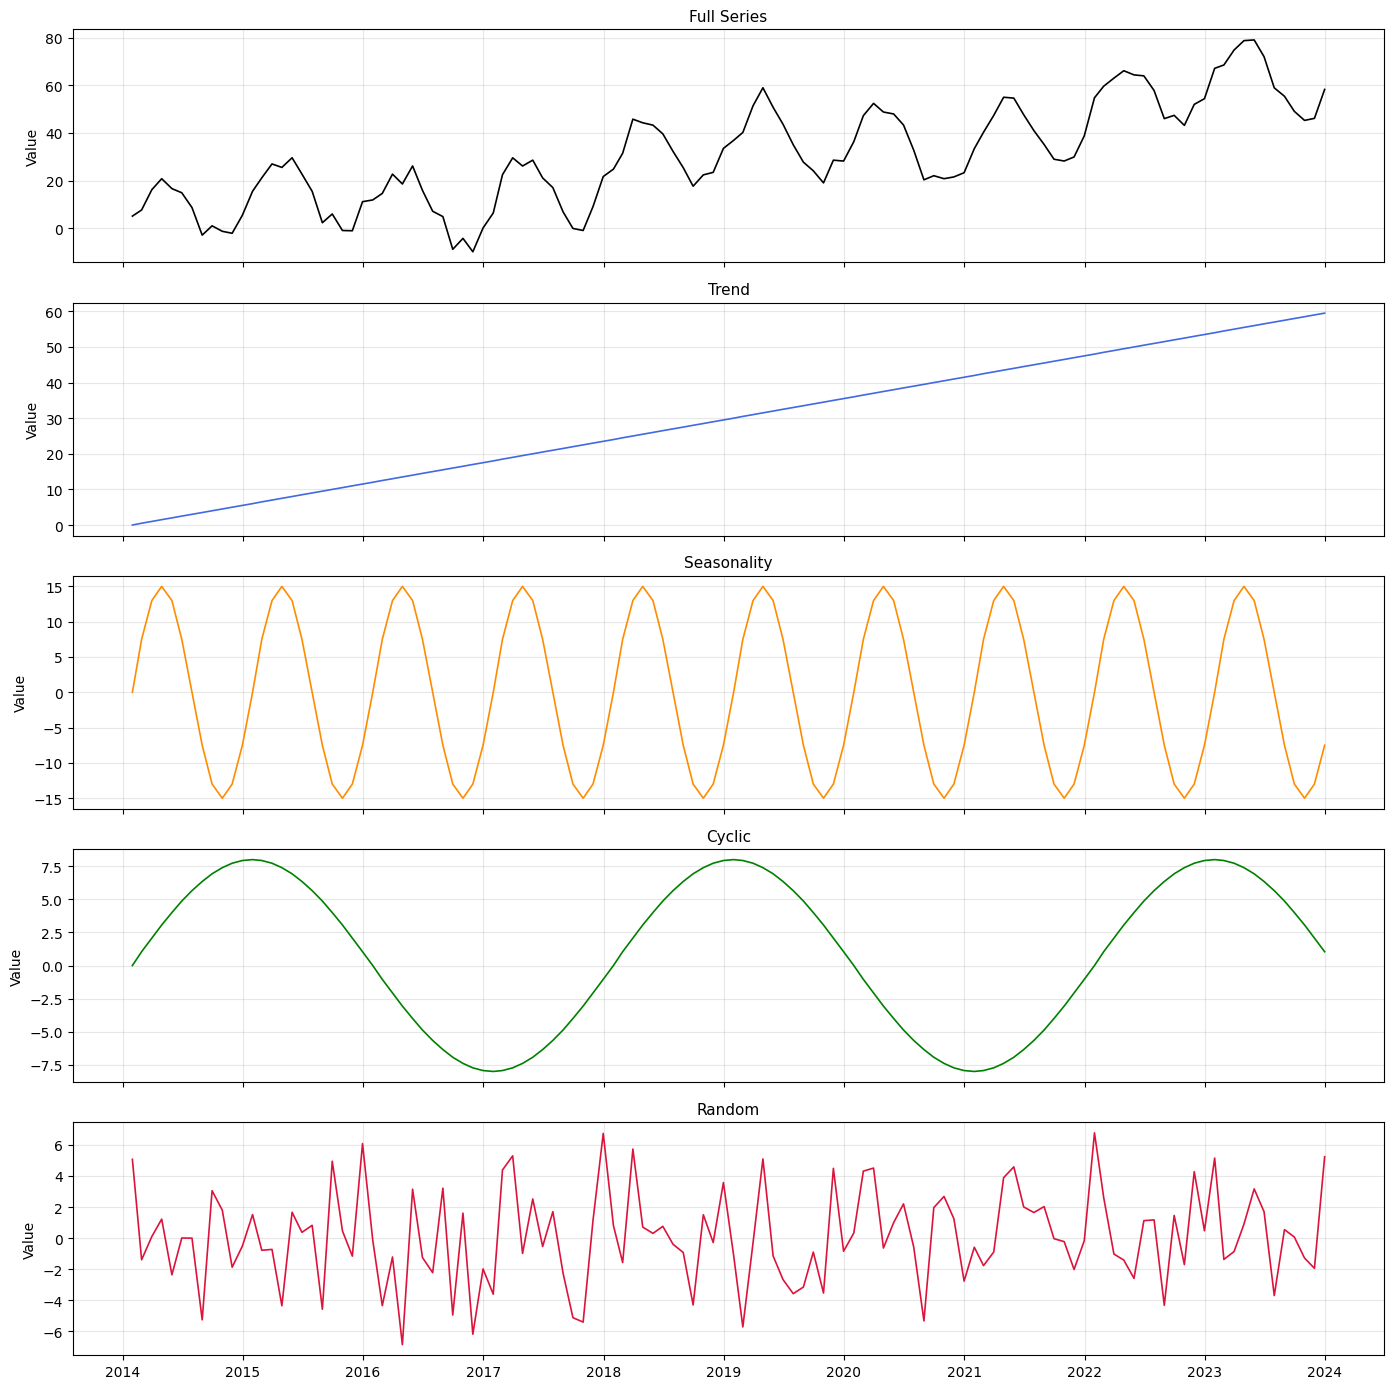

In [7]:
# --- EXAMPLE: Synthetic series with known components ---

np.random.seed(7)
t = np.arange(120)  # 10 years of monthly data
dates_ex = pd.date_range('2014-01', periods=120, freq='ME')

trend      = 0.5 * t
seasonality = 15 * np.sin(2 * np.pi * t / 12)
cyclic     = 8 * np.sin(2 * np.pi * t / 48)
random     = np.random.normal(0, 3, 120)

y = trend + seasonality + cyclic + random
series_ex = pd.Series(y, index=dates_ex, name='synthetic')

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ax, data, title, color in zip(
    axes,
    [y, trend, seasonality, cyclic, random],
    ['Full Series', 'Trend', 'Seasonality', 'Cyclic', 'Random'],
    ['black', 'royalblue', 'darkorange', 'green', 'crimson']
):
    ax.plot(dates_ex, data, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

### Exercise 3.1 — Seasonal Decomposition

Use `seasonal_decompose` from `statsmodels` to decompose `series_ex`. Set `model='additive'` and `period=12`. Plot all four components using the result's `.plot()` method.

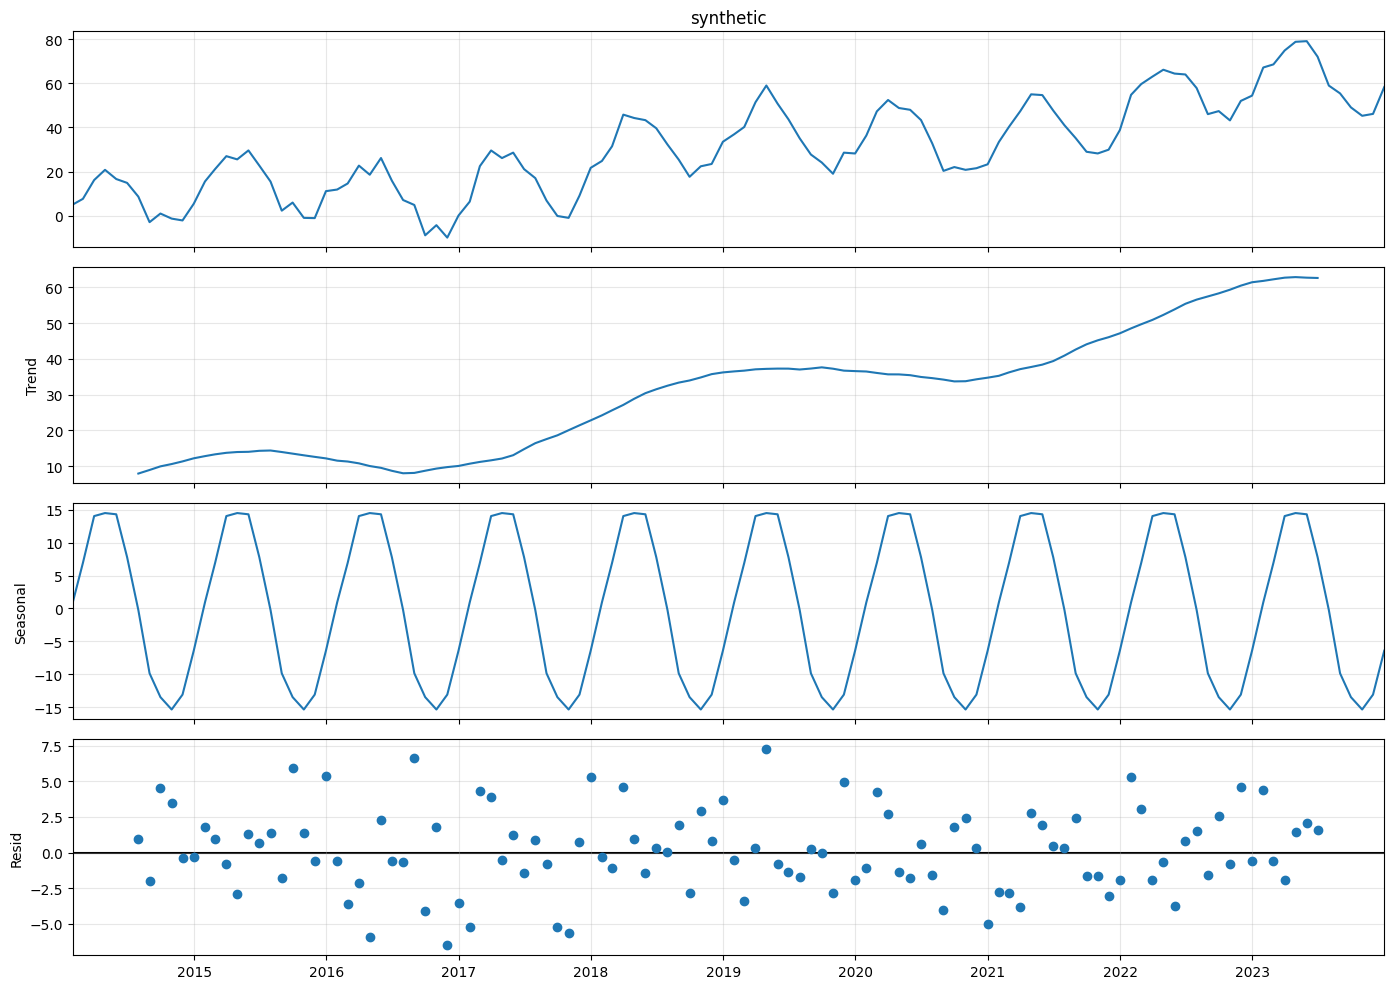

In [8]:
# Exercise 3.1 Solution
decomposition = seasonal_decompose(series_ex, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

### Exercise 3.2 — Short Answer

**Your answers here:**

1. The **residual** component represents what remains after removing the trend, seasonal, and cyclic patterns — essentially unexplained noise. A large residual at a specific point suggests that an unusual or anomalous event occurred there that the model cannot account for (e.g. a sudden shock, data error, or one-time event like a natural disaster or market crash).

2. A **multiplicative** decomposition is preferred when the amplitude of the seasonal fluctuations (and/or noise) grows proportionally with the level of the series. A real-world example is airline passenger numbers: as overall travel increases over decades, the summer peak and winter trough also grow larger in absolute terms — not by a fixed amount, but by a fixed *multiplier* of the current level.

---
## Section 4 — Moving Averages

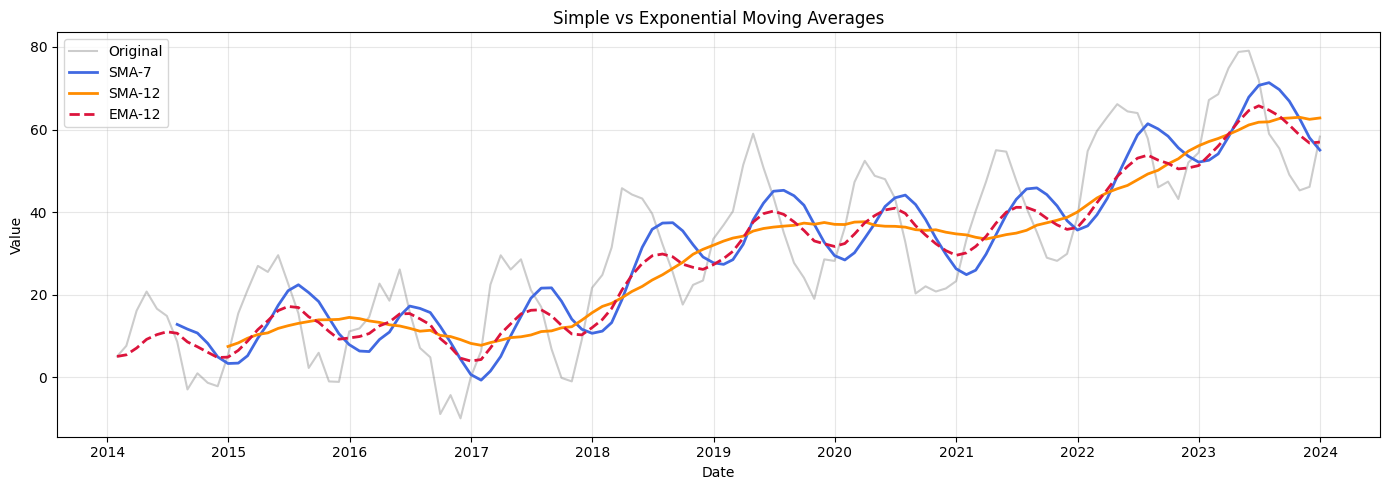

In [9]:
# --- EXAMPLE: SMA vs EMA ---

sma_7  = series_ex.rolling(window=7).mean()
sma_12 = series_ex.rolling(window=12).mean()
ema_12 = series_ex.ewm(span=12, adjust=False).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(series_ex.index, series_ex, alpha=0.4, color='gray', label='Original')
ax.plot(sma_7.index,  sma_7,  color='royalblue',   linewidth=2, label='SMA-7')
ax.plot(sma_12.index, sma_12, color='darkorange',   linewidth=2, label='SMA-12')
ax.plot(ema_12.index, ema_12, color='crimson',      linewidth=2, label='EMA-12', linestyle='--')
ax.set_title('Simple vs Exponential Moving Averages')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 4.1 — Rolling Statistics on Sales

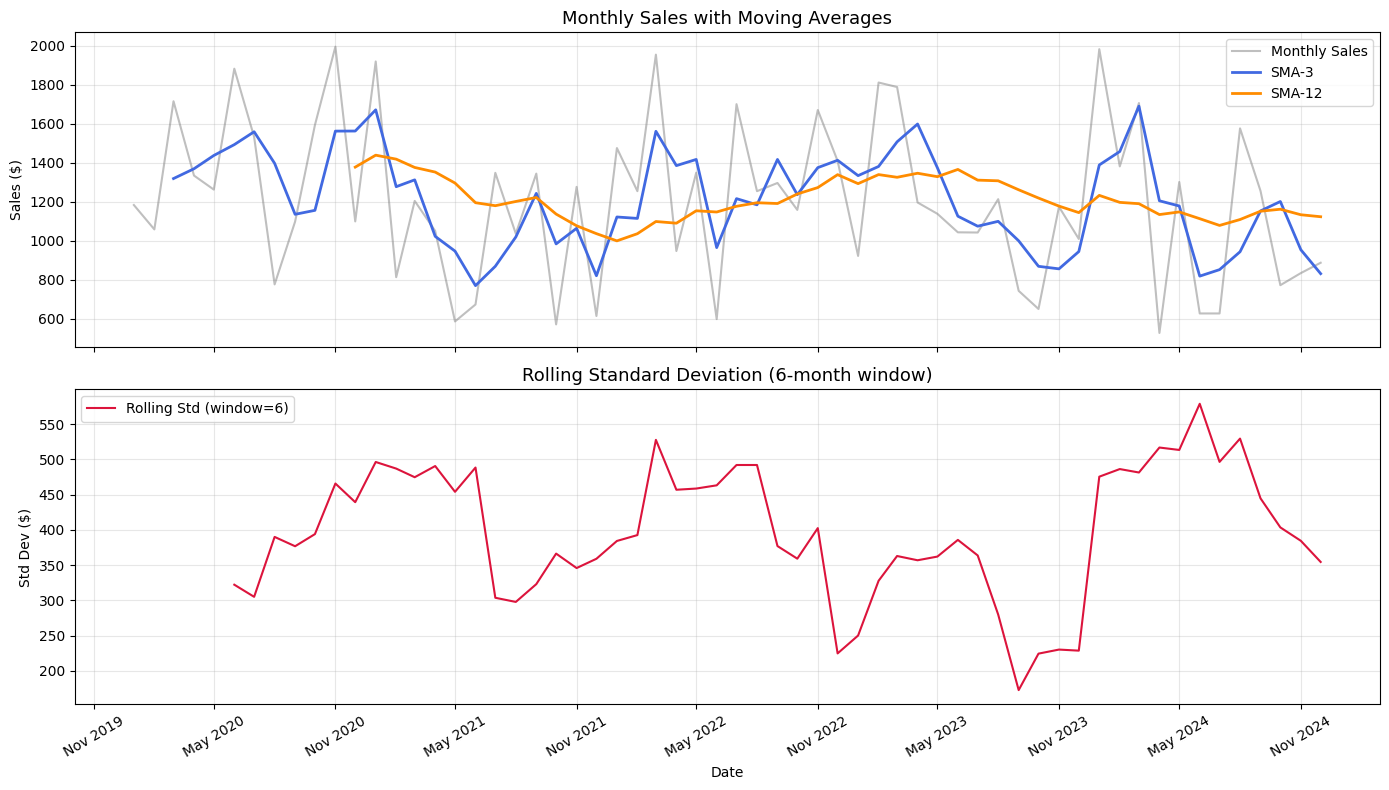

In [10]:
# Exercise 4.1 Solution
sma_3    = sales.rolling(window=3).mean()
sma_12   = sales.rolling(window=12).mean()
roll_std = sales.rolling(window=6).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: original + SMAs
ax1.plot(sales.index, sales.values, alpha=0.5, color='gray', label='Monthly Sales')
ax1.plot(sma_3.index, sma_3, color='royalblue', linewidth=2, label='SMA-3')
ax1.plot(sma_12.index, sma_12, color='darkorange', linewidth=2, label='SMA-12')
ax1.set_title('Monthly Sales with Moving Averages', fontsize=13)
ax1.set_ylabel('Sales ($)')
ax1.legend()

# Bottom: rolling std
ax2.plot(roll_std.index, roll_std, color='crimson', linewidth=1.5, label='Rolling Std (window=6)')
ax2.set_title('Rolling Standard Deviation (6-month window)', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Std Dev ($)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

plt.tight_layout()
plt.show()

### Exercise 4.2 — Short Answer

**Your answers here:**

1. The SMA produces `NaN` values at the start because it needs `window` observations to compute the first average — there simply aren't enough prior data points yet. Setting `min_periods=1` (or a smaller integer) tells pandas to compute the mean from however many values are available so far, filling in partial averages instead of `NaN`.

2. The EMA assigns exponentially decreasing weights to older observations, so it reacts more quickly to recent changes in the series. For forecasting, this means it tracks recent trends more closely and lags behind the true series less than an SMA of the same span — making it more responsive to shifts in level or momentum.

---
## Section 5 — Lag Features

In [11]:
# --- EXAMPLE: Building a lag feature DataFrame ---

df_lags = pd.DataFrame({'value': series_ex})

for lag in [1, 2, 3, 6, 12]:
    df_lags[f'lag_{lag}'] = df_lags['value'].shift(lag)

print("Shape:", df_lags.shape)
print("\nFirst 15 rows (notice NaN at start):")
print(df_lags.head(15).round(2))

Shape: (120, 6)

First 15 rows (notice NaN at start):
            value  lag_1  lag_2  lag_3  lag_6  lag_12
2014-01-31   5.07    NaN    NaN    NaN    NaN     NaN
2014-02-28   7.65   5.07    NaN    NaN    NaN     NaN
2014-03-31  16.16   7.65   5.07    NaN    NaN     NaN
2014-04-30  20.78  16.16   7.65   5.07    NaN     NaN
2014-05-31  16.62  20.78  16.16   7.65    NaN     NaN
2014-06-30  14.88  16.62  20.78  16.16    NaN     NaN
2014-07-31   8.65  14.88  16.62  20.78   5.07     NaN
2014-08-31  -2.92   8.65  14.88  16.62   7.65     NaN
2014-09-30   0.99  -2.92   8.65  14.88  16.16     NaN
2014-10-31  -1.31   0.99  -2.92   8.65  20.78     NaN
2014-11-30  -2.14  -1.31   0.99  -2.92  16.62     NaN
2014-12-31   5.42  -2.14  -1.31   0.99  14.88     NaN
2015-01-31  15.52   5.42  -2.14  -1.31   8.65    5.07
2015-02-28  21.15  15.52   5.42  -2.14  -2.92    7.65
2015-03-31  26.99  21.15  15.52   5.42   0.99   16.16


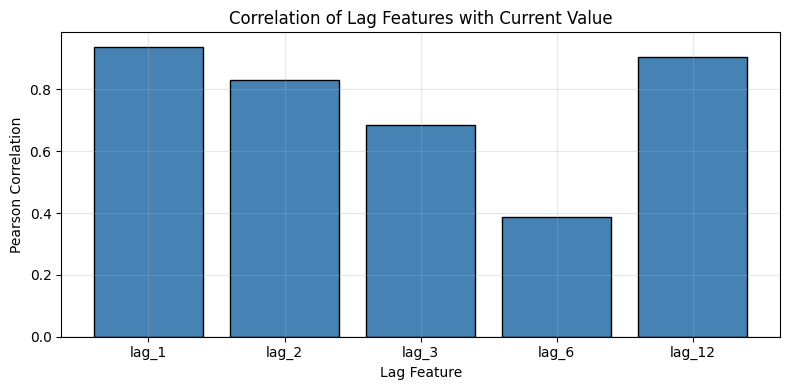

In [12]:
# --- EXAMPLE: Lag correlation plot ---
df_clean = df_lags.dropna()
correlations = {col: df_clean['value'].corr(df_clean[col])
                for col in df_clean.columns if col != 'value'}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(correlations.keys(), correlations.values(), color='steelblue', edgecolor='black')
ax.set_title('Correlation of Lag Features with Current Value')
ax.set_xlabel('Lag Feature')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Exercise 5.1 — Lag Features for Sales

        sales  lag_1  lag_2  lag_3  lag_6  lag_12
sales   1.000 -0.066  0.264 -0.210  0.151   0.150
lag_1  -0.066  1.000 -0.083  0.247 -0.260  -0.238
lag_2   0.264 -0.083  1.000 -0.058  0.077   0.066
lag_3  -0.210  0.247 -0.058  1.000 -0.243  -0.122
lag_6   0.151 -0.260  0.077 -0.243  1.000   0.151
lag_12  0.150 -0.238  0.066 -0.122  0.151   1.000


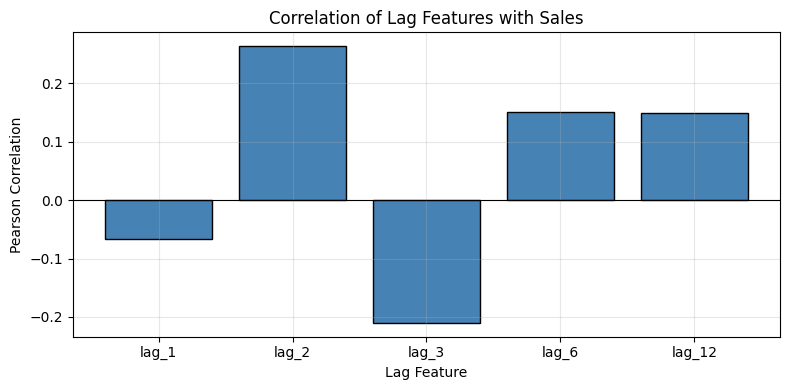

In [13]:
# Exercise 5.1 Solution
df_sales = pd.DataFrame({'sales': sales})

# 1. Add lag features
for lag in [1, 2, 3, 6, 12]:
    df_sales[f'lag_{lag}'] = df_sales['sales'].shift(lag)

# 2. Drop NaNs
df_sales = df_sales.dropna()

# 3. Correlation matrix
print(df_sales.corr().round(3))

# 4. Bar chart of lag correlations with target
lag_cols = [c for c in df_sales.columns if c != 'sales']
lag_corrs = {col: df_sales['sales'].corr(df_sales[col]) for col in lag_cols}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lag_corrs.keys(), lag_corrs.values(), color='steelblue', edgecolor='black')
ax.set_title('Correlation of Lag Features with Sales')
ax.set_xlabel('Lag Feature')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Exercise 5.2 — Short Answer

**Your answers here:**

1. An agent using `lag_1` and `lag_2` is capturing **short-term momentum** — recent local trends, sudden spikes or dips, and the autocorrelation structure from one or two steps back. An agent using `lag_12` is capturing **annual seasonality** — the idea that the same month last year is a strong predictor of the current month's value. In a multi-agent system, the first agent specialises in short-run dynamics while the second encodes long-run seasonal memory; combining their outputs allows the ensemble to model both.

2. If you use a lag feature without dropping `NaN` rows first, the model training will either throw an error or silently treat `NaN` as a valid value (depending on the library). This corrupts the model — rows with `NaN` features cannot contribute a valid gradient or loss signal, and many algorithms (e.g. scikit-learn estimators) will refuse to fit at all, raising a `ValueError`.

---
## Section 6 — Putting It All Together

We'll use the **Air Passengers** dataset — monthly international airline passengers from 1949–1960.

In [14]:
# Load the Air Passengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
air = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
air.columns = ['passengers']
air.index.freq = 'MS'
print(air.head())
print("\nShape:", air.shape)

            passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Shape: (144, 1)


### Exercise 6.1 — Full EDA

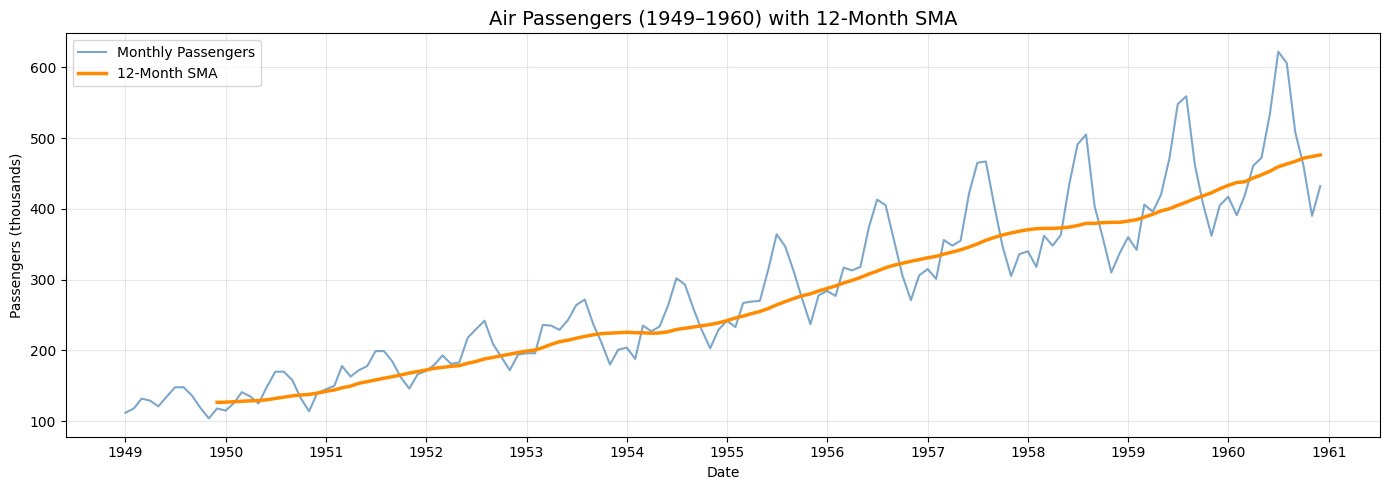

In [15]:
# Part 1 & 2: Raw series + 12-month SMA
air_sma12 = air['passengers'].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(air.index, air['passengers'], color='steelblue', linewidth=1.5,
        alpha=0.7, label='Monthly Passengers')
ax.plot(air_sma12.index, air_sma12, color='darkorange', linewidth=2.5,
        label='12-Month SMA')
ax.set_title('Air Passengers (1949–1960) with 12-Month SMA', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
plt.tight_layout()
plt.show()

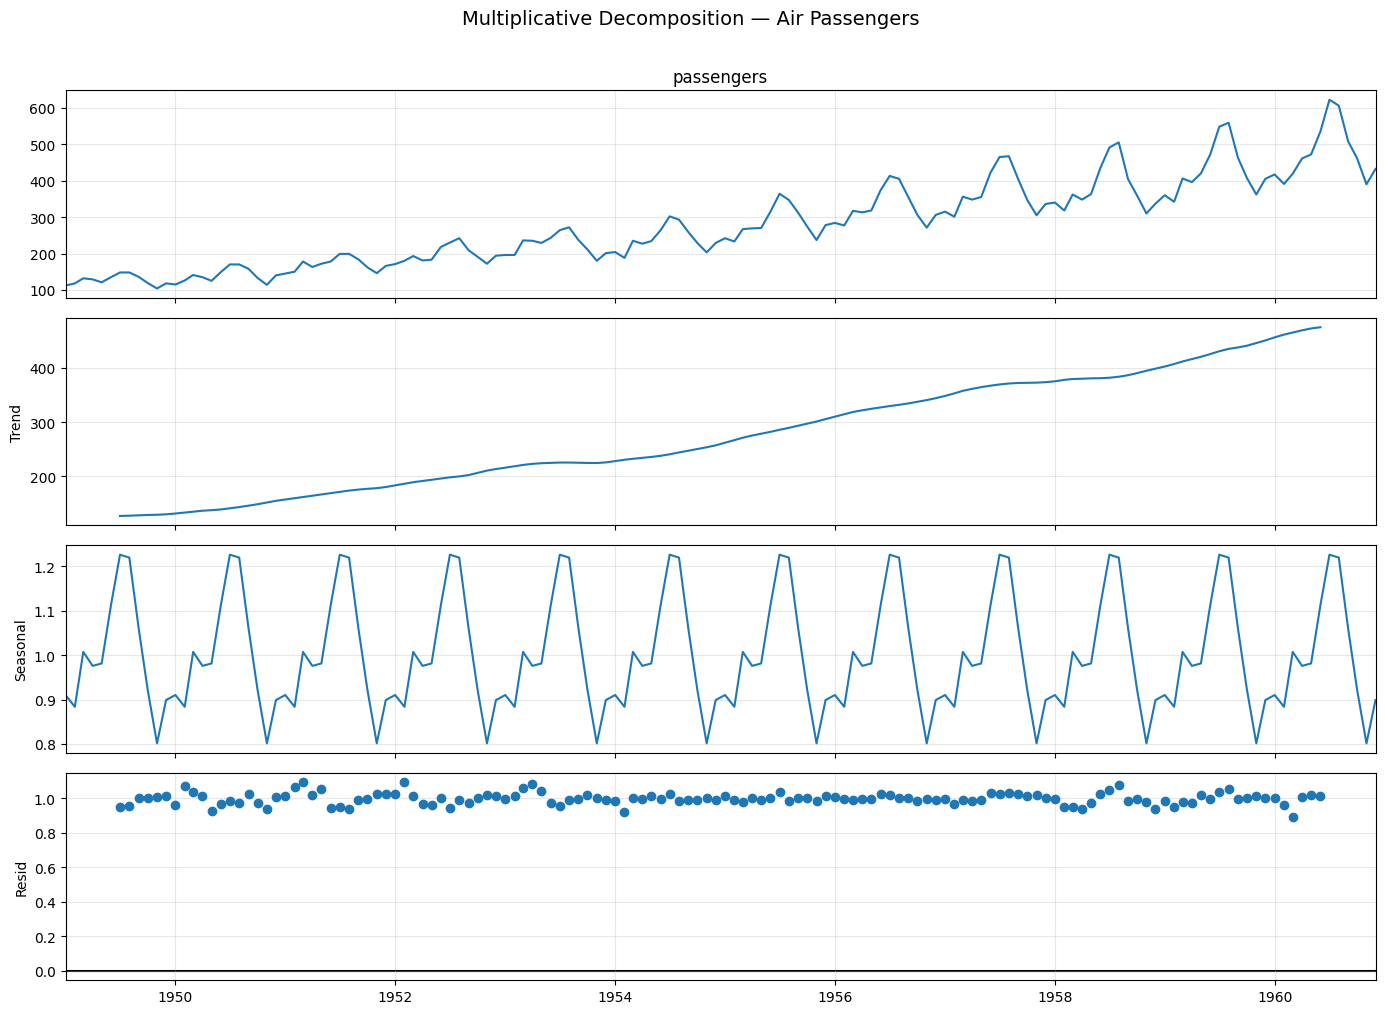

In [16]:
# Part 3: Multiplicative decomposition
decomp_air = seasonal_decompose(air['passengers'], model='multiplicative', period=12)

fig = decomp_air.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Multiplicative Decomposition — Air Passengers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

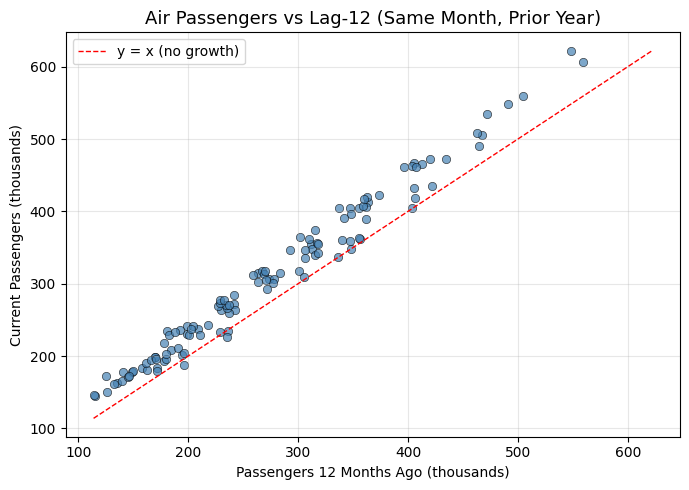

Correlation matrix:
            passengers  lag_1  lag_12  lag_24
passengers       1.000  0.945   0.989   0.983
lag_1            0.945  1.000   0.940   0.936
lag_12           0.989  0.940   1.000   0.988
lag_24           0.983  0.936   0.988   1.000


In [17]:
# Part 4 & 5: Lag features + scatter plot
df_air = pd.DataFrame({'passengers': air['passengers']})
for lag in [1, 12, 24]:
    df_air[f'lag_{lag}'] = df_air['passengers'].shift(lag)

df_air_clean = df_air.dropna()

# Scatter: passengers vs lag_12
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_air_clean['lag_12'], df_air_clean['passengers'],
           color='steelblue', alpha=0.7, edgecolors='black', linewidths=0.5)
ax.set_title('Air Passengers vs Lag-12 (Same Month, Prior Year)', fontsize=13)
ax.set_xlabel('Passengers 12 Months Ago (thousands)')
ax.set_ylabel('Current Passengers (thousands)')

# Add a reference line (y = x)
lims = [df_air_clean[['passengers', 'lag_12']].min().min(),
        df_air_clean[['passengers', 'lag_12']].max().max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='y = x (no growth)')
ax.legend()
plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(df_air_clean.corr().round(3))

### Exercise 6.2 — Reflection

**Your answer here:**

The Air Passengers dataset exhibits a strong upward **trend** (passenger counts roughly triple from 1949 to 1960) and pronounced **seasonality** with a consistent annual cycle (peaks in summer, troughs in winter). Because the seasonal swings grow in absolute size as the level rises, the series is clearly **multiplicative** rather than additive — the decomposition confirms this with a near-constant seasonal component once expressed as a ratio. There is little evidence of a distinct cyclic component beyond the yearly pattern, and the residuals are small relative to the signal. For a forecasting model, `lag_12` (same month last year) would be the highest-priority feature given the near-perfect linear scatter plot and correlation above 0.97; `lag_1` would add short-term momentum. In a multi-agent system, these lags map naturally to specialised agents: a *seasonal agent* anchored on `lag_12` and `lag_24` would handle the annual rhythm, while a *momentum agent* using `lag_1` and `lag_2` would capture month-to-month drift — their outputs can then be combined by a meta-learner for a more robust forecast than either alone.

---
## Bonus Challenge ⭐

Combine moving averages and lag features into a single feature-engineered DataFrame for the Air Passengers dataset.

In [18]:
# BONUS Solution
df_feat = pd.DataFrame({'passengers': air['passengers']})

# Lag features
df_feat['lag_1']  = df_feat['passengers'].shift(1)
df_feat['lag_12'] = df_feat['passengers'].shift(12)

# Moving averages
df_feat['sma_3']  = df_feat['passengers'].rolling(window=3).mean()
df_feat['sma_12'] = df_feat['passengers'].rolling(window=12).mean()

# Rolling standard deviation
df_feat['rolling_std_6'] = df_feat['passengers'].rolling(window=6).std()

# Month as integer (encodes seasonality)
df_feat['month'] = df_feat.index.month

# Drop NaN rows (lag_12 introduces the most)
df_feat = df_feat.dropna()

print("Final shape:", df_feat.shape)
print("\nFirst 5 rows:")
print(df_feat.head())

Final shape: (132, 7)

First 5 rows:
            passengers  lag_1  lag_12       sma_3      sma_12  rolling_std_6  \
Month                                                                          
1950-01-01         115  118.0   112.0  112.333333  126.916667      15.870308   
1950-02-01         126  115.0   118.0  119.666667  127.583333      10.745542   
1950-03-01         141  126.0   132.0  127.333333  128.333333      12.340989   
1950-04-01         135  141.0   129.0  134.000000  128.833333      13.614943   
1950-05-01         125  135.0   121.0  133.666667  129.166667       9.892758   

            month  
Month              
1950-01-01      1  
1950-02-01      2  
1950-03-01      3  
1950-04-01      4  
1950-05-01      5  


---
## Submission Checklist

Before submitting, make sure:
- [x] All `# YOUR CODE HERE` cells are filled in and run without errors
- [x] All short-answer cells are filled in
- [x] All plots have titles, axis labels, and legends
- [x] The notebook runs top-to-bottom with **Kernel → Restart & Run All**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week1_Assignment_YourName.ipynb`